In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv("C:/Users/M S I/Downloads/OneDrive_2025-09-18/Predicting Olympic medal counts/data/olympics2016.csv")

# Check for missing values in tot16
print(f"\nMissing values in tot16: {df['tot16'].isnull().sum()}")


# 1. Check for Overdispersion
print("\n" + "="*50)
print("OVERDISPERSION CHECK")
print("="*50)

mean_tot16 = df['tot16'].mean()
var_tot16 = df['tot16'].var()

print(f"Mean of tot16: {mean_tot16:.2f}")
print(f"Variance of tot16: {var_tot16:.2f}")
print(f"Variance/Mean ratio: {var_tot16/mean_tot16:.2f}")

# Rule of thumb for overdispersion
if var_tot16 / mean_tot16 > 1.5:
    print("✅ STRONG evidence of overdispersion (variance >> mean)")
elif var_tot16 / mean_tot16 > 1.2:
    print("⚠️  Moderate evidence of overdispersion")
else:
    print("❌ No significant overdispersion detected")

# 2. Check for Zero-Inflation with Negative Binomial
print("\n" + "="*50)
print("ZERO-INFLATION CHECK")
print("="*50)

# Count zeros and non-zeros
zeros = (df['tot16'] == 0).sum()
non_zeros = (df['tot16'] > 0).sum()
total = len(df)

print(f"Countries with 0 medals: {zeros} ({zeros/total*100:.1f}%)")
print(f"Countries with >0 medals: {non_zeros} ({non_zeros/total*100:.1f}%)")

# Estimate Negative Binomial parameters using method of moments
if var_tot16 > mean_tot16:
    # Negative Binomial parameters: mean = mu, variance = mu + alpha*mu^2
    # alpha = (variance - mean) / mean^2
    alpha = (var_tot16 - mean_tot16) / (mean_tot16 ** 2)
    # For NB2 parameterization: p = mu / (mu + 1/alpha), n = 1/alpha
    p_nb = mean_tot16 / (mean_tot16 + 1/alpha) if alpha > 0 else 0.5
    n_nb = 1/alpha if alpha > 0 else 1
    
    # Probability of zero under Negative Binomial: P(X=0) = (1-p)^n
    prob_zero_nb = (1 - p_nb) ** n_nb
    expected_zeros_nb = prob_zero_nb * total
    
    print(f"\n--- Negative Binomial Distribution ---")
    print(f"Alpha (dispersion parameter): {alpha:.4f}")
    print(f"NB parameters: n={n_nb:.4f}, p={p_nb:.4f}")
    print(f"Probability of zero under NB: {prob_zero_nb:.4f}")
    print(f"Expected zeros under NB: {expected_zeros_nb:.1f}")
    print(f"Excess zeros (NB): {zeros - expected_zeros_nb:.1f}")
    
else:
    print("No overdispersion detected - Negative Binomial not appropriate")
    expected_zeros_nb = expected_zeros_poisson  # Fallback to Poisson

# Zero-inflation assessment for both distributions
print(f"\n--- ZERO-INFLATION ASSESSMENT ---")

# Negative Binomial assessment (if applicable)
if var_tot16 > mean_tot16:
    nb_zero_ratio = zeros / expected_zeros_nb if expected_zeros_nb > 0 else float('inf')
    print(f"Negative Binomial zero ratio (actual/expected): {nb_zero_ratio:.2f}")
    
    if nb_zero_ratio > 1.5:
        print("✅ STRONG evidence of zero-inflation relative to Negative Binomial")
        print("   → Zero-Inflated Negative Binomial model recommended")
    elif nb_zero_ratio > 1.2:
        print("⚠️  Moderate evidence of zero-inflation relative to Negative Binomial")
        print("   → Consider Zero-Inflated Negative Binomial model")
    else:
        print("❌ No significant zero-inflation relative to Negative Binomial")
        print("   → Standard Negative Binomial model sufficient")

df


Missing values in tot16: 0

OVERDISPERSION CHECK
Mean of tot16: 8.96
Variance of tot16: 287.29
Variance/Mean ratio: 32.05
✅ STRONG evidence of overdispersion (variance >> mean)

ZERO-INFLATION CHECK
Countries with 0 medals: 25 (23.1%)
Countries with >0 medals: 83 (76.9%)

--- Negative Binomial Distribution ---
Alpha (dispersion parameter): 3.4646
NB parameters: n=0.2886, p=0.9688
Probability of zero under NB: 0.3676
Expected zeros under NB: 39.7
Excess zeros (NB): -14.7

--- ZERO-INFLATION ASSESSMENT ---
Negative Binomial zero ratio (actual/expected): 0.63
❌ No significant zero-inflation relative to Negative Binomial
   → Standard Negative Binomial model sufficient


,country,country.code,gdp00,gdp04,gdp08,gdp12,gdp16,pop00,pop04,pop08,...,totmedals12,totmedals16,bmi,altitude,athletes00,athletes04,athletes08,athletes12,athletes16,host
0,Afghanistan,AFG,NaN,5285,10191,20537,19469.0,20094,24119,27294,...,956,949,23.30,1790.0,0,5,4,6,3,0
1,Algeria,DZA,54790.0,85325,171001,209059,159049.0,31184,32831,34861,...,956,949,25.60,1.0,47,61,56,38,64,0
2,Argentina,ARG,284204.0,164658,361558,545982,554861.0,37057,38729,40382,...,956,949,27.75,10.5,143,152,132,137,215,0
3,Armenia,ARM,1912.0,3577,11662,10619,10546.0,3070,3001,2908,...,956,949,NaN,989.0,25,18,25,24,31,0
4,Australia,AUS,415034.0,611904,1052585,1543411,1208039.0,19153,20127,21249,...,956,949,27.25,605.0,617,470,432,404,420,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,United States,USA,10284779.0,12274928,14718582,16155255,18624475.0,282162,292805,304094,...,956,949,29.00,2.0,586,533,588,530,555,1
104,Uzbekistan,UZB,13760.0,12030,29549,51822,67068.0,24650,25864,27303,...,956,949,NaN,459.0,70,69,56,53,70,0
105,Venezuela,VEN,117141.0,112453,315953,381286,236.0,24488,26327,28142,...,956,949,26.80,909.0,50,48,108,68,86,0
106,Vietnam,VNM,31173.0,45428,99130,155820,205276.0,80286,83528,86708,...,956,949,21.70,25.0,7,11,13,18,22,0


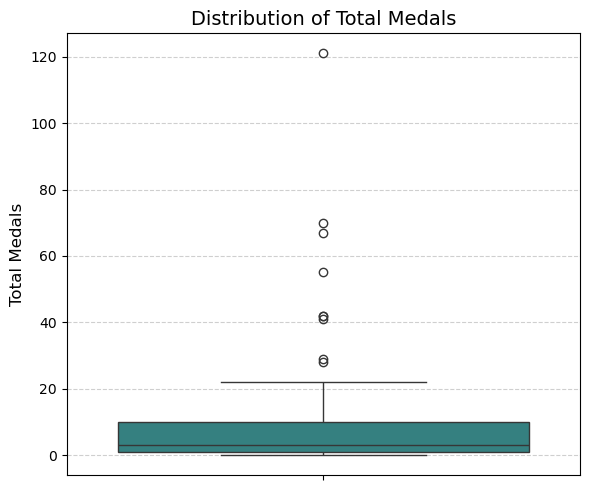

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.boxplot(y=df['tot16'], color='#298c8c')

plt.title('Distribution of Total Medals', fontsize=14)
plt.ylabel('Total Medals', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

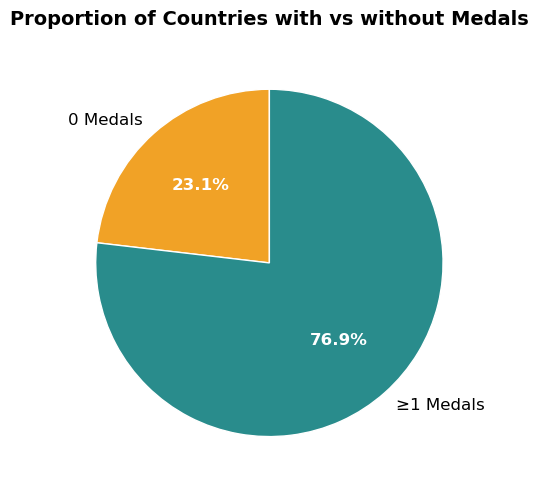

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# --- Pie Chart: Countries with 0 vs Non-zero Medals ---
zero_count = (df['tot16'] == 0).sum()
non_zero_count = (df['tot16'] > 0).sum()

fig, ax = plt.subplots(figsize=(5,5))
wedges, texts, autotexts = ax.pie(
    [zero_count, non_zero_count],
    labels=['0 Medals', '≥1 Medals'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#f1a226', '#298c8c'],
    textprops={'fontsize': 12},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
for text in texts + autotexts:
    text.set_fontsize(12)
plt.setp(autotexts, weight="bold", color="white")
ax.set_title('Proportion of Countries with vs without Medals',
             fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import glm, poisson, negativebinomial
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Read the CSV file
df = pd.read_csv("C:/Users/M S I/Downloads/OneDrive_2025-09-18/Predicting Olympic medal counts/data/olympics2016.csv")

# Data preparation
print("Data Preparation...")
print("="*50)

# Identify potential predictors (excluding identifiers and redundant columns)
potential_predictors = [
    'gdp00', 'gdp04', 'gdp08', 'gdp12', 'gdp16', 'pop00', 'pop04', 'pop08', 'pop12', 'pop16', 
    'soviet', 'comm', 'muslim', 'oneparty', 'gold00', 'gold04', 'gold08', 'gold12', 'gold16', 
    'tot00', 'tot04', 'tot08', 'tot12', 'totgold00', 'totgold04', 'totgold08', 'totgold12', 'totgold16', 
    'totmedals00', 'totmedals04', 'totmedals08', 'totmedals12', 'totmedals16', 'bmi', 'altitude', 
    'athletes00', 'athletes04', 'athletes08', 'athletes12', 'athletes16', 'host'
]

# Identify countries with missing gdp16 and gdp00
missing_gdp16 = df[df['gdp16'].isnull()]['country'].tolist()
missing_gdp00 = df[df['gdp00'].isnull()]['country'].tolist()

print(f"Countries with missing gdp16: {missing_gdp16}")
print(f"Countries with missing gdp00: {missing_gdp00}")

# Select relevant numeric variables for KNN imputation
# Choose variables that are correlated with GDP
predictor_columns = ['gdp12', 'gdp08', 'gdp04', 'gdp00', 'gdp16',  # Include both target variables
                    'pop16', 'pop12', 'pop08', 'pop04', 'pop00', 
                    'soviet', 'comm', 'muslim', 'oneparty']

# Filter to only include columns that exist in the dataset
available_predictors = [col for col in predictor_columns if col in df.columns]
print(f"Using predictors: {available_predictors}")

# Create a subset with both GDP variables and predictors
# We'll impute gdp00 and gdp16 together since they're related
impute_data = df[['gdp00', 'gdp16'] + [p for p in available_predictors if p not in ['gdp00', 'gdp16']]].copy()

print(f"\nData for imputation shape: {impute_data.shape}")
print(f"Missing values before imputation:")
print(f"gdp00: {impute_data['gdp00'].isnull().sum()}")
print(f"gdp16: {impute_data['gdp16'].isnull().sum()}")

# Standardize the data (important for KNN)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(impute_data)

# Apply KNN imputation
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(scaled_data)

# Convert back to original scale
imputed_data_original = scaler.inverse_transform(imputed_data)

# Create DataFrame with imputed values
imputed_df = pd.DataFrame(imputed_data_original, 
                         columns=impute_data.columns,
                         index=df.index)

# Get the imputed GDP values for the missing countries
imputed_gdp00_values = imputed_df.loc[df['gdp00'].isnull(), 'gdp00']
imputed_gdp16_values = imputed_df.loc[df['gdp16'].isnull(), 'gdp16']

print("\n" + "=" * 50)
print("KNN IMPUTATION RESULTS")
print("=" * 50)

print("\nGDP00 Imputation Results:")
for i, (idx, value) in enumerate(imputed_gdp00_values.items()):
    country = df.loc[idx, 'country']
    original_value = df.loc[idx, 'gdp00']
    print(f"{country}: {value:,.0f} (imputed)")

print("\nGDP16 Imputation Results:")
for i, (idx, value) in enumerate(imputed_gdp16_values.items()):
    country = df.loc[idx, 'country']
    original_value = df.loc[idx, 'gdp16']
    print(f"{country}: {value:,.0f} (imputed)")

# ADD THE IMPUTED VALUES DIRECTLY TO ORIGINAL COLUMNS (NO NEW COLUMNS)
print("\n" + "=" * 50)
print("UPDATING ORIGINAL COLUMNS")
print("=" * 50)

# Store original missing counts
missing_gdp00_before = df['gdp00'].isnull().sum()
missing_gdp16_before = df['gdp16'].isnull().sum()

# Update the original columns with imputed values
df.loc[df['gdp00'].isnull(), 'gdp00'] = imputed_gdp00_values
df.loc[df['gdp16'].isnull(), 'gdp16'] = imputed_gdp16_values

# Check results
missing_gdp00_after = df['gdp00'].isnull().sum()
missing_gdp16_after = df['gdp16'].isnull().sum()

print(f"Missing values before imputation:")
print(f"gdp00: {missing_gdp00_before}")
print(f"gdp16: {missing_gdp16_before}")

print(f"\nMissing values after imputation:")
print(f"gdp00: {missing_gdp00_after}")
print(f"gdp16: {missing_gdp16_after}")

# Handle missing values - impute with median for continuous variables
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())

print(f"\nFinal dataset shape: {df.shape}")
print(f"Variables: {list(df.columns)}")

# 2. Univariate Significance Testing
print("\n" + "="*50)
print("2. UNIVARIATE SIGNIFICANCE TESTING")
print("="*50)

# Test each predictor individually
univariate_results = []

for predictor in potential_predictors:
    if predictor != 'tot16':
        # Remove rows where either variable is missing
        temp_df = df[[predictor, 'tot16']].dropna()
        
        if len(temp_df) > 10:  # Ensure sufficient data
            # Pearson correlation test for continuous variables
            if temp_df[predictor].nunique() > 10:  # Continuous variable
                try:
                    corr, p_value = stats.pearsonr(temp_df[predictor], temp_df['tot16'])
                    test_type = "Pearson"
                except:
                    continue
            else:  # Categorical/binary variable
                # Group by predictor and compare means
                groups = [group['tot16'].values for name, group in temp_df.groupby(predictor)]
                if len(groups) >= 2:
                    try:
                        f_stat, p_value = stats.f_oneway(*groups)
                        corr = np.sqrt(f_stat / (f_stat + len(temp_df) - len(groups)))
                        test_type = "ANOVA"
                    except:
                        continue
                else:
                    continue
              
            univariate_results.append({
                'predictor': predictor,
                'correlation': corr,
                'p_value': p_value,
                'test_type': test_type,
                'significant': p_value < 0.05,
                'n_obs': len(temp_df)
            })

# Display univariate results
if univariate_results:
    univariate_df = pd.DataFrame(univariate_results)
    univariate_df = univariate_df.sort_values('p_value')
    print("\nUnivariate Significance Results:")
    print(univariate_df.to_string(index=False))
    
    # Show top 20 most significant predictors
    print(f"\nTop 20 Most Significant Predictors:")
    top_predictors = univariate_df.head(20)
    for i, row in top_predictors.iterrows():
        stars = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"{row['predictor']:20} : r={row['correlation']:6.3f} p={row['p_value']:.2e} {stars}")
else:
    print("No significant results found.")

Data Preparation...
Countries with missing gdp16: ['Cuba', 'Syrian Arab Republic']
Countries with missing gdp00: ['Afghanistan']
Using predictors: ['gdp12', 'gdp08', 'gdp04', 'gdp00', 'gdp16', 'pop16', 'pop12', 'pop08', 'pop04', 'pop00', 'soviet', 'comm', 'muslim', 'oneparty']

Data for imputation shape: (108, 14)
Missing values before imputation:
gdp00: 1
gdp16: 2

KNN IMPUTATION RESULTS

GDP00 Imputation Results:
Afghanistan: 42,653 (imputed)

GDP16 Imputation Results:
Cuba: 62,427 (imputed)
Syrian Arab Republic: 51,636 (imputed)

UPDATING ORIGINAL COLUMNS
Missing values before imputation:
gdp00: 1
gdp16: 2

Missing values after imputation:
gdp00: 0
gdp16: 0

Final dataset shape: (108, 44)
Variables: ['country', 'country.code', 'gdp00', 'gdp04', 'gdp08', 'gdp12', 'gdp16', 'pop00', 'pop04', 'pop08', 'pop12', 'pop16', 'soviet', 'comm', 'muslim', 'oneparty', 'gold00', 'gold04', 'gold08', 'gold12', 'gold16', 'tot00', 'tot04', 'tot08', 'tot12', 'tot16', 'totgold00', 'totgold04', 'totgold0

               gdp00     gdp04     gdp08     gdp12     gdp16     pop00  \
gdp00       1.000000  0.974241  0.890153  0.798675  0.671890  0.255382   
gdp04       0.974241  1.000000  0.954609  0.852210  0.743903  0.321139   
gdp08       0.890153  0.954609  1.000000  0.953566  0.881260  0.502972   
gdp12       0.798675  0.852210  0.953566  1.000000  0.971449  0.671862   
gdp16       0.671890  0.743903  0.881260  0.971449  1.000000  0.765816   
pop00       0.255382  0.321139  0.502972  0.671862  0.765816  1.000000   
pop04       0.250129  0.314997  0.494493  0.661759  0.755166  0.999744   
pop08       0.244944  0.309013  0.486227  0.651774  0.744508  0.999011   
pop12       0.239543  0.302824  0.478092  0.642293  0.734391  0.997942   
pop16       0.235064  0.297807  0.471501  0.634519  0.726121  0.996757   
gold00      0.369875  0.489589  0.635744  0.649707  0.629146  0.402042   
gold04      0.534720  0.615235  0.747666  0.790043  0.755145  0.476766   
gold08      0.458008  0.568562  0.7382

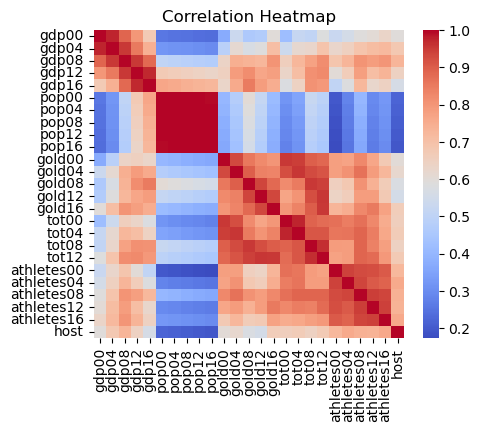

In [9]:
import pandas as pd

# Sort by the target
df_sorted = df.sort_values(by='tot16', ascending=False)

# Keep all but the top 1 point
n_remove = 1
df_filtered = df_sorted.iloc[n_remove:]  # drops the top n_remove rows

# Optional: reset index
df_filtered = df_filtered.reset_index(drop=True)

# Drop unnecessary rows
df_upd = df_filtered.drop(columns=['country','country.code','oneparty','altitude','bmi','muslim','comm','soviet', 'totgold00', 'totgold04', 'totgold08', 'totgold12', 'totgold16', 
    'totmedals00', 'totmedals04', 'totmedals08', 'totmedals12', 'totmedals16','tot16'])
df_upd

# Assuming df is your DataFrame
corr_matrix = df_upd.corr()

# Display as text
print(corr_matrix)

corr_matrix = df_upd.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, 
            annot=False,     # No numbers
            xticklabels=True,  # Hide x-axis labels
            yticklabels=True,  # Hide y-axis labels
            cmap='coolwarm',   # Color map for heat
            cbar=True)         # Show color bar

plt.title('Correlation Heatmap')
plt.show()

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import NegativeBinomial

# Python equivalent of R's glm.nb()
m = glm('tot16 ~ gdp00 + gdp04 + gdp08 + gdp12 + gdp16 + pop00 + pop04 + pop08 + pop12 + pop16 + gold00 + gold04 + gold08 + gold12 + gold16 + tot00 + tot04 + tot08 + tot12 + athletes00 + athletes04 + athletes08 + athletes12 + athletes16 + host', data=df, family=sm.families.NegativeBinomial()).fit()

print(m.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  tot16   No. Observations:                  108
Model:                            GLM   Df Residuals:                       82
Model Family:        NegativeBinomial   Df Model:                           25
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -270.65
Date:                Tue, 18 Nov 2025   Deviance:                       75.114
Time:                        02:47:07   Pearson chi2:                     58.4
No. Iterations:                    18   Pseudo R-squ. (CS):             0.7728
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2905      0.184      1.578      0.1

C:\Users\M S I\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [13]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df_upd.values
Y = df_filtered['tot16']

# Standardize features before PCA (important!)
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[ 1.76394927,  2.50842619,  4.69397644, ...,  2.78447218,
         2.81974399,  2.22361068],
       [ 2.53868077,  3.17760841,  2.76185599, ...,  4.27806741,
         2.51876502,  2.22361068],
       [ 0.07531446,  0.44847833,  1.37048287, ...,  3.31445759,
         1.81334556,  2.22361068],
       ...,
       [-0.38377807, -0.44074491, -0.50354414, ..., -0.80979248,
        -0.53805265, -0.44971901],
       [-0.36369131, -0.42120731, -0.48022485, ..., -0.75197589,
        -0.77319247, -0.44971901],
       [-0.37365306, -0.4351086 , -0.50369123, ..., -0.76161199,
        -0.58508062, -0.44971901]])

      PC  Explained_Variance  Cumulative_Variance
0    PC1        6.765602e-01             0.676560
1    PC2        1.691141e-01             0.845674
2    PC3        6.820319e-02             0.913877
3    PC4        3.322274e-02             0.947100
4    PC5        1.638052e-02             0.963481
5    PC6        1.363852e-02             0.977119
6    PC7        7.160520e-03             0.984280
7    PC8        3.392970e-03             0.987673
8    PC9        2.318551e-03             0.989991
9   PC10        2.273643e-03             0.992265
10  PC11        1.992517e-03             0.994257
11  PC12        1.395099e-03             0.995653
12  PC13        9.955122e-04             0.996648
13  PC14        8.300323e-04             0.997478
14  PC15        6.797116e-04             0.998158
15  PC16        5.513975e-04             0.998709
16  PC17        4.688521e-04             0.999178
17  PC18        3.519547e-04             0.999530
18  PC19        2.987212e-04             0.999829


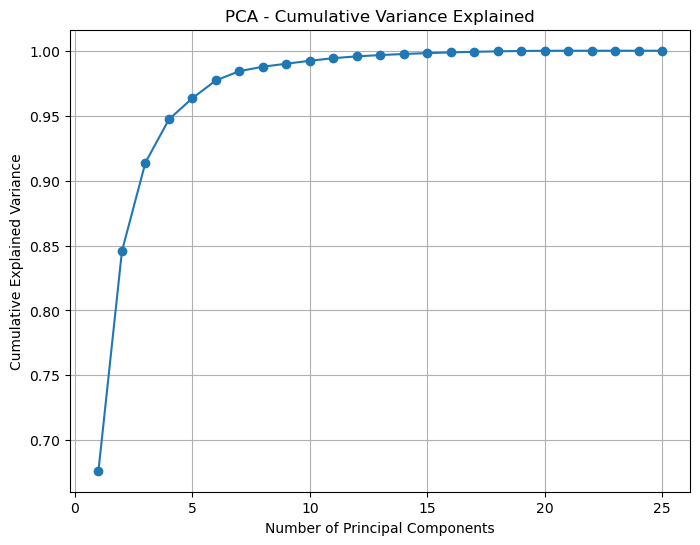

array([[ 1.62215359e-01,  1.87147491e-01,  2.18258184e-01,
         2.21613070e-01,  2.13895340e-01,  1.48272395e-01,
         1.45769934e-01,  1.43369790e-01,  1.41141771e-01,
         1.39335249e-01,  2.09336854e-01,  2.24208258e-01,
         2.23066070e-01,  2.15890938e-01,  2.20276283e-01,
         2.09879748e-01,  2.19167112e-01,  2.31035699e-01,
         2.33062539e-01,  1.98840287e-01,  2.06150358e-01,
         2.26153451e-01,  2.15140213e-01,  2.07947646e-01,
         1.77679524e-01],
       [-6.98745044e-02, -7.11867878e-02, -1.17805018e-02,
         8.88477875e-02,  1.59987383e-01,  3.81627887e-01,
         3.84716930e-01,  3.87364111e-01,  3.89602064e-01,
         3.91246004e-01, -8.31292514e-02, -5.29797910e-02,
         3.92683375e-02,  2.06690127e-04, -7.31220121e-02,
        -1.42329324e-01, -1.28205149e-01, -3.12050862e-02,
        -4.84054773e-02, -2.08375223e-01, -1.67404020e-01,
        -1.14796414e-01, -1.61821311e-01, -1.36550252e-01,
        -1.47608573e-01],
    

In [17]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Put into DataFrame for easy viewing
variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

print(variance_df)

# Plot cumulative variance
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Variance Explained")
plt.grid(True)
plt.show()

In [27]:
import pandas as pd

# your PCA feature names
feature_names = df_upd.columns

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print(loadings)


                 PC1       PC2       PC3       PC4       PC5       PC6  \
gdp00       0.162215 -0.069875  0.524404 -0.134709 -0.238331 -0.160647   
gdp04       0.187147 -0.071187  0.453336 -0.108241 -0.128607 -0.090619   
gdp08       0.218258 -0.011781  0.319815 -0.073110 -0.057564 -0.000913   
gdp12       0.221613  0.088848  0.234137 -0.127383 -0.078249  0.016838   
gdp16       0.213895  0.159987  0.156342 -0.174775  0.019363  0.062993   
pop00       0.148272  0.381628 -0.033458  0.108616 -0.012581 -0.001175   
pop04       0.145770  0.384717 -0.030392  0.120938 -0.012458 -0.003966   
pop08       0.143370  0.387364 -0.027781  0.132743 -0.012616 -0.006361   
pop12       0.141142  0.389602 -0.026241  0.142951 -0.013147 -0.008482   
pop16       0.139335  0.391246 -0.025169  0.150949 -0.013817 -0.010739   
gold00      0.209337 -0.083129 -0.293801 -0.085647 -0.301881  0.088567   
gold04      0.224208 -0.052980 -0.162680 -0.120067 -0.338770 -0.029824   
gold08      0.223066  0.039268 -0.1734

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Step 3: Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# --- Step 4: PCA (keep 6 components) ---
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)  # use the same PCA for test set

# --- Step 5: Add constant for intercept ---
X_train_pca_const = sm.add_constant(X_train_pca)
X_test_pca_const = sm.add_constant(X_test_pca)

# --- Step 6: Negative Binomial Regression ---
# --- Step 6: Negative Binomial Regression (compatible with ZINB) ---
from statsmodels.discrete.count_model import NegativeBinomialP

nb_model = NegativeBinomialP(y_train, X_train_pca_const)
nb_results = nb_model.fit(maxiter=200, disp=False)
print(nb_results.summary())

# Define inflation predictors (simplify to intercept-only for stability)
exog_infl_train = np.ones((len(X_train_pca_const), 1))
exog_infl_test  = np.ones((len(X_test_pca_const), 1))

# Define parameter counts
n_count = X_train_pca_const.shape[1]  # const + 6 PCs
n_infl  = exog_infl_train.shape[1]    # just intercept
n_total = n_count + n_infl + 1        # +1 for alpha

# Build the start_params vector using NB coefficients
start_params = np.concatenate([
    nb_params[:n_count],     # count model params
    np.zeros(n_infl),        # inflation params start at 0
    [0.5]                    # dispersion alpha
])

print(f"Start params length: {len(start_params)} (expected {n_total})")


print(results.summary())

# --- Step 7: Predict on test set ---
y_pred = results.predict(X_test_pca_const)

# --- Step 8: Evaluate ---
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nTest Set Evaluation:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from statsmodels.genmod.families.links import log, sqrt, identity
from sklearn.preprocessing import RobustScaler

# --- Step 3: Train-test split ---
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X_scaled, Y, df_filtered.index, test_size=0.2, random_state=42)

# --- Step 4: PCA (keep 6 components) ---
pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# --- Step 5: Add constant for intercept ---
X_train_pca_const = sm.add_constant(X_train_pca)
X_test_pca_const = sm.add_constant(X_test_pca)

# --- Step 6: Zero-Inflated Negative Binomial ---
# exog_infl: predictors for the zero-inflation part (can be same as X or subset)
zinb_model = ZeroInflatedNegativeBinomialP(
    endog=y_train,
    exog=X_train_pca_const,
    exog_infl=X_train_pca_const,  # zero-inflation predictors
    inflation='logit', #changing inflation and link fn did not help
    p = 1 #1 gave better results than 2
)
zinb_results = zinb_model.fit(maxiter=100, method='bfgs')  # more iterations did not help
print(zinb_results.summary())

# Predict on test set
y_pred = zinb_results.predict(exog=X_test_pca_const, exog_infl=X_test_pca_const)

# --- Step 8: Evaluate ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nTest Set Evaluation:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")


In [ ]:
# Round predictions to nearest integer (optional, since counts are discrete)
y_pred_rounded = y_pred.round().astype(int)

# Get country names for the test set
countries_test = df_filtered.loc[idx_test, 'country'].values

# Combine with actual values in a DataFrame
predictions_df = pd.DataFrame({
    'Country': countries_test,
    'Actual': y_test.values,
    'Predicted': y_pred_rounded,
})

print(predictions_df)

In [ ]:
# Reset index to start from 1
predictions_df = predictions_df.reset_index(drop=True)
predictions_df.index = predictions_df.index + 1

# --- Styling for aesthetics ---
styled_df = (
    predictions_df.style
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#6faa63'),
                                     ('color', 'white'),
                                     ('border', '1px solid black'),
                                     ('text-align', 'center')]},
         # Body cells styling
        {'selector': 'td', 'props': [('border', '1px solid black'),
                                     ('text-align', 'center'),
                                     ('background-color', '#eff6ee') ]},  # light gray
    ])
    .set_properties(**{'text-align': 'center'})
)

# Display styled DataFrame
styled_df

In [ ]:
# Print test set evaluation in layman terms
print("\nModel Accuracy on Test Set:")
print(f"- On average, the model's prediction is off by {mae:.2f} medals per country (MAE).")
print(f"The predictions are usually within ±{rmse:.2f} medals of actual counts.")

In [ ]:
predictions_df.to_csv(r"C:\Users\M S I\Downloads\olympicsresult.csv", index=False)